# Домашнее задание 2. StarGAN

## Этап 1. Установка зависимостей, инициализация и загрузка данных

В этом разделе мы работаем с датасетом CelebA, содержащим изображения лиц с набором атрибутов. Целью задания является генерация новых изображений лиц с заданными характеристиками.

In [1]:
%pip install lpips comet_ml -q

import sys
sys.path.append('../../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from lpips import LPIPS
from torchvision import transforms
from munch import Munch
from tqdm.auto import trange
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CelebA

# from datasets.celeba import CelebADataset

device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)

/home/jovyan/vasiliev/notebooks/DeepGenerativeModels/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


/home/jovyan/vasiliev/notebooks/DeepGenerativeModels/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
args = Munch()
args.img_size = 256  # Размер изображений после преобразования

# Создание последовательности преобразований для подготовки изображений
transform=transforms.Compose([
    transforms.Resize(args.img_size),
    transforms.CenterCrop(args.img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# Загрузка датасета CelebA с применением указанных преобразований
# dataset = CelebADataset(
#     root_dir='../../seminars/data/celeba',
#     transform=transform)
dataset = CelebA(root='data/img_aligngn_celeba', download=False, transform=transform)
# dataset = CelebA()
# Число потоков для загрузки данных
num_workers = 0 if device.type == 'cuda' else 2
# Whether to put fetched data tensors to pinned memory
pin_memory = True if device.type == 'cuda' else False

# args.batch_size = ...   # Задайте размер батча
args.batch_size = 4

# Создание DataLoader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=args.batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
    shuffle=True
)

In [3]:
dataset[0]

(tensor([[[ 2.2489,  2.2489,  2.2489,  ...,  2.1975,  2.1804,  2.1633],
          [ 2.2489,  2.2489,  2.2489,  ...,  2.1975,  2.1633,  2.1462],
          [ 2.2489,  2.2489,  2.2489,  ...,  2.1804,  2.1462,  2.1290],
          ...,
          [ 0.5878,  0.7762,  0.9303,  ...,  0.7762,  0.7419,  0.7419],
          [ 0.7933,  0.8961,  1.0159,  ...,  0.9132,  0.8447,  0.8447],
          [ 1.1529,  1.0331,  1.0331,  ...,  1.1187,  1.1700,  1.1700]],
 
         [[ 2.0784,  2.0784,  2.0784,  ...,  2.2010,  2.1835,  2.2010],
          [ 2.0784,  2.0784,  2.0784,  ...,  2.1835,  2.1835,  2.2010],
          [ 2.0784,  2.0784,  2.0784,  ...,  2.1835,  2.1835,  2.1835],
          ...,
          [-0.4426, -0.2325, -0.0924,  ...,  0.0301,  0.0126,  0.0126],
          [-0.2325, -0.1275, -0.0049,  ...,  0.1877,  0.1176,  0.1176],
          [ 0.1352,  0.0126,  0.0126,  ...,  0.3978,  0.4503,  0.4503]],
 
         [[ 1.6465,  1.6465,  1.6465,  ...,  2.2217,  2.2217,  2.2217],
          [ 1.6465,  1.6465,

In [4]:
# args.num_domains = ...  # Задайте число доменов
args.num_domains = len(dataset.attr_names)

### Визуализация датасета

In [5]:
# # Визуализация случайно выбранных изображений из датасета

# _, axes = plt.subplots(ncols=3, nrows=3, figsize=(15, 15))
# for i, img_idx in enumerate(np.random.choice(range(len(dataset)), 9)):

#     img, target = dataset[img_idx]
#     img = (img - img.min()) / (img.max() - img.min())
#     axes[i // 3][i % 3].imshow(img.detach().cpu().numpy().transpose(1, 2, 0))

## Этап 2. Инициализация и обучение модели

В этом этапе необходимо реализовать и обучить модель StarGAN для генерации лиц с заданными атрибутами.

Вы можете выбрать одну из следующих моделей:
- [StarGANv1](https://arxiv.org/pdf/1711.09020.pdf) (**до 4 баллов**)
- [StarGANv2](https://arxiv.org/abs/1912.01865) (**до 7 баллов**)

### Инициализация

Ниже приведён шаблон для определения основных компонентов модели. Реализуйте их по своему усмотрению.

In [6]:
import torch.nn.functional as F
import torch.nn as nn
from tqdm import tqdm

STYLE_CODE_DIM = 64
DOMAINS_COUNT = 41
Z_DIM = 16
LAMBDA_STY = 1.0
LAMBDA_DS = 1.0
LAMBDA_CYC = 1.0

In [7]:
class AdaIn(nn.Module):
    def __init__(self, feature_size, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        
        self.linear_gamma = nn.Linear(STYLE_CODE_DIM, feature_size)
        self.linear_beta = nn.Linear(STYLE_CODE_DIM, feature_size)

    def forward(self, content: torch.Tensor, style: torch.Tensor) -> torch.Tensor:
        content_mean = content.mean(dim=(2, 3), keepdim=True)
        content_std = content.std(dim=(2, 3), keepdim=True)
        normalized = (content - content_mean) / (content_std + self.eps)
        
        gamma = self.linear_gamma(style)[..., None, None]
        beta = self.linear_beta(style)[..., None, None]
        
        return gamma * normalized + beta

In [8]:
from enum import Enum, auto

class Resample(Enum):
    NONE = auto()
    UP = auto()
    DOWN = auto()

In [9]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, norm=None, resample=Resample.NONE):
        super().__init__()
        
        self.is_AdaIn = norm == AdaIn
        
        self.resample = resample
        self.avgpool = nn.AvgPool2d(2)

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        
        self.norm1 = norm(out_channels) if norm else nn.Identity()

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.norm2 = norm(out_channels) if norm else nn.Identity()

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU(inplace=True)
        

    def forward(self, x, style=None):
        identity = x
        
        if self.resample == Resample.UP:
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            identity = F.interpolate(identity, scale_factor=2, mode="bilinear", align_corners=False)

        out = self.conv1(x)
        if self.is_AdaIn:
            if style is None:
                raise ValueError("style must be provided when using AdaIn")
            out = self.norm1(out, style)
        else:
            out = self.norm1(out)
        out = self.relu(out)

        out = self.conv2(out)
        if self.is_AdaIn:
            out = self.norm2(out, style)
        else:
            out = self.norm2(out)
        
        if self.resample == Resample.DOWN:
            out = self.avgpool(out)
            identity = self.avgpool(identity)
            
        out += self.shortcut(identity)
        out = self.relu(out)

        return out

In [10]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_in = nn.Conv2d(3, 64, 1)
        self.res_blocks_with_instance_norm = nn.Sequential(
            ResNetBlock(64, 128, norm=nn.InstanceNorm2d, resample=Resample.DOWN),
            ResNetBlock(128, 256, norm=nn.InstanceNorm2d, resample=Resample.DOWN),
            ResNetBlock(256, 512, norm=nn.InstanceNorm2d, resample=Resample.DOWN),
            ResNetBlock(512, 512, norm=nn.InstanceNorm2d, resample=Resample.DOWN),
            ResNetBlock(512, 512, norm=nn.InstanceNorm2d),
            ResNetBlock(512, 512, norm=nn.InstanceNorm2d),
        )
        
        self.res_blocks_with_adaptive_instance_norm = nn.ModuleList([
            ResNetBlock(512, 512, norm=AdaIn, resample=Resample.UP),
            ResNetBlock(512, 256, norm=AdaIn, resample=Resample.UP),
            ResNetBlock(256, 128, norm=AdaIn, resample=Resample.UP),
            ResNetBlock(128, 64, norm=AdaIn, resample=Resample.UP),
        ])
        self.conv_out = nn.Conv2d(64, 3, 7, padding=3)

    def forward(self, x, style_code):
        out = self.conv_in(x)
        out = self.res_blocks_with_instance_norm(out)
        for block in self.res_blocks_with_adaptive_instance_norm:
            out = block(out, style=style_code)
            
        out = self.conv_out(out)
        return out

In [11]:
class MappingNetwork(nn.Module):
    def __init__(self, hid_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, DOMAINS_COUNT * STYLE_CODE_DIM),
            nn.ReLU(),
        )
        
    def forward(self, latent_code):
        style_codes_for_all_domains = self.net(latent_code)
        batch_size = latent_code.shape[0]
        style_codes_for_all_domains = style_codes_for_all_domains.reshape(batch_size, DOMAINS_COUNT, STYLE_CODE_DIM)
        return style_codes_for_all_domains

In [12]:
class Encoder(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        
        self.conv_in = nn.Conv2d(3, 64, 1)
        self.net = nn.Sequential(
            ResNetBlock(64, 128, resample=Resample.DOWN),
            ResNetBlock(128, 256, resample=Resample.DOWN),
            ResNetBlock(256, 512, resample=Resample.DOWN),
            ResNetBlock(512, 512, resample=Resample.DOWN),
            ResNetBlock(512, 512, resample=Resample.DOWN),
            ResNetBlock(512, 512, resample=Resample.DOWN),
            nn.LeakyReLU(),
            nn.Conv2d(512, 512, 4),
            nn.LeakyReLU(),
            nn.Flatten(), # 512
            nn.Linear(512, out_dim)
        )
        

    def forward(self, x):
        out = self.conv_in(x)
        out = self.net(out)
        return out

In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = Encoder(DOMAINS_COUNT)
    
    def forward(self, image):
        return self.net(image)

In [14]:
class StyleEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = Encoder(STYLE_CODE_DIM * DOMAINS_COUNT)
    
    def forward(self, image):
        out = self.net(image)
        bs = image.shape[0]
        
        out = out.reshape(bs, DOMAINS_COUNT, STYLE_CODE_DIM)
        return out

In [15]:
from dataclasses import dataclass
from typing import List
import random

@dataclass
class Samples:
    images: torch.Tensor
    domains: int

In [16]:
a = torch.ones(20)[None, ...].repeat_interleave(10, 0)

print(a.shape)

# random_domains = [random.randint(1, DOMAINS_COUNT+1), for range(1, )]
print(a[:, (1, 4)].shape)

torch.Size([10, 20])
torch.Size([10, 2])


In [17]:
import torch.nn.functional as F

def l_adv_d(discriminator, real_images, fake_images, real_domains, target_domains):
    """Hinge adversarial loss for discriminator."""
    batch_size = real_images.shape[0]
    dev = real_images.device
    real_out = discriminator(real_images)[torch.arange(batch_size, device=dev), real_domains]
    fake_out = discriminator(fake_images.detach())[torch.arange(batch_size, device=dev), target_domains]
    return torch.mean(F.relu(1 - real_out)) + torch.mean(F.relu(1 + fake_out))

def l_adv_g(discriminator, fake_images, target_domains):
    """Adversarial loss for generator."""
    batch_size = fake_images.shape[0]
    dev = fake_images.device
    fake_out = discriminator(fake_images)[torch.arange(batch_size, device=dev), target_domains]
    return -torch.mean(fake_out)

In [18]:
def l_sty(style_encoder, generator, images, style_codes, domain_indices):
    generated_images = generator(images, style_codes)
    reconstructed_style_codes = style_encoder(generated_images)  # [batch_size, DOMAINS_COUNT, STYLE_CODE_DIM]
    
    batch_size = images.shape[0]
    reconstructed_selected = reconstructed_style_codes[torch.arange(batch_size), domain_indices]
    
    return torch.nn.functional.l1_loss(style_codes, reconstructed_selected)

In [19]:
def l_ds(generator, images, style_codes_1, style_codes_2): # стайл коды тут из маппинг нетворка s ̃i = Fy ̃(zi)
    return torch.nn.functional.l1_loss(generator(images, style_codes_1), generator(images, style_codes_2))

In [20]:
def l_cyc(generator, style_encoder, images, original_domain_indices, style_codes):
    batch_size = images.shape[0]
    hat_style_codes = style_encoder(images)[torch.arange(batch_size), original_domain_indices]
    generated_by_random_style = generator(images, style_codes)
    generated = generator(generated_by_random_style, hat_style_codes)
    
    return torch.nn.functional.l1_loss(images, generated)
    

In [21]:
# Создание структуры для хранения компонентов модели

nets = Munch()
# nets.generator = ...           # Генератор, отвечающий за преобразование изображений
# nets.mapping_network = ...     # Сеть маппинга: преобразует латентный вектор в стиль
# nets.style_encoder = ...       # Энкодер стиля: извлекает стиль из изображений
# nets.discriminator = ...       # Дискриминатор: оценивает реалистичность сгенерированных изображений

### Обучение

In [52]:
# Create G & D
generator = Generator()
discriminator = Discriminator()
style_encoder = StyleEncoder()
mapping_network = MappingNetwork()

generator.to(device)
discriminator.to(device)
style_encoder.to(device)
mapping_network.to(device)

# Create optimizers
optim_G = torch.optim.Adam(generator.parameters(), lr=1e-4)
optim_D = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))
optim_F = torch.optim.Adam(mapping_network.parameters(), lr=1e-6)
optim_E = torch.optim.Adam(style_encoder.parameters(), lr=1e-3)

# Create schedulers
scheduler_G = torch.optim.lr_scheduler.StepLR(optim_G, step_size=20, gamma=0.5)
scheduler_D = torch.optim.lr_scheduler.StepLR(optim_D, step_size=20, gamma=0.5)
scheduler_F = torch.optim.lr_scheduler.StepLR(optim_F, step_size=20, gamma=0.5)
scheduler_E = torch.optim.lr_scheduler.StepLR(optim_E, step_size=20, gamma=0.5)

losses = {"D": [], "G": []}
num_epochs = 1

In [53]:
def get_random_domain_indices(domains):
    weights = domains.float() + 1e-8
    selected_indices = torch.multinomial(weights, num_samples=1).squeeze(-1)
    return selected_indices

In [54]:
def denormalize_image(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(img, 0, 1)

def show_image(ax, img_tensor, title):
    img = denormalize_image(img_tensor)
    img_np = img.permute(1, 2, 0).detach().cpu().numpy()
    ax.imshow(img_np, interpolation='bilinear')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def visualize_generations_with_mapping(generator, mapping_network, dataloader, device, num_styles=5):
    generator.eval()
    mapping_network.eval()
    
    with torch.no_grad():
        real_images, _ = next(iter(dataloader))
        x_real = real_images[0:1].to(device)
        
        z = torch.randn(1, Z_DIM).to(device)
        style_codes_all = mapping_network(z)
        
        fig, axes = plt.subplots(num_styles, 2, figsize=(10, 3 * num_styles))
        if num_styles == 1:
            axes = axes.reshape(1, -1)
        
        for style_idx in range(num_styles):
            row = axes[style_idx] if num_styles > 1 else axes
            
            
            show_image(row[0], x_real[0].cpu(), 'Original')
            
            selected_style_code = style_codes_all[0, style_idx].unsqueeze(0)
            x_fake = generator(x_real, selected_style_code)
            
            print(f'{x_fake[0].shape=}')
            show_image(row[1], x_fake[0].cpu(), f'Generated (Style {style_idx})')
        
        plt.tight_layout()
        plt.show()
    
    generator.train()
    mapping_network.train()

In [55]:
def visualize_generations(generator, mapping_network, style_encoder, dataloader, device, num_styles=5):
    generator.eval()
    mapping_network.eval()
    style_encoder.eval()
    
    with torch.no_grad():
        real_images, _ = next(iter(dataloader))
        x_real = real_images[0:1].to(device)
        
        x_ref, _ = next(iter(dataloader))
        x_ref = x_ref.to(device)
        
        fig, axes = plt.subplots(num_styles, 3, figsize=(15, 3 * num_styles))
        if num_styles == 1:
            axes = axes.reshape(1, -1)
        
        for style_idx in range(num_styles):
            row = axes[style_idx] if num_styles > 1 else axes
            
            show_image(row[0], x_real[0].cpu(), 'Original')
            
            ref_idx = style_idx % x_ref.shape[0]
            print(f'{x_ref[ref_idx].shape=}')
            show_image(row[1], x_ref[ref_idx].cpu(), f'Reference (Style {style_idx})')
            
            style_codes_ref = style_encoder(x_ref[ref_idx:ref_idx+1])
            selected_style_code = style_codes_ref[0, style_idx].unsqueeze(0)
            x_fake = generator(x_real, selected_style_code)
            
            show_image(row[2], x_fake[0].cpu(), f'Generated (Style {style_idx})')
        
        plt.tight_layout()
        plt.show()
    
    generator.train()
    mapping_network.train()
    style_encoder.train()

In [56]:
from IPython.display import display, clear_output

loss_history = {
    "total": [], "adv": [], "sty": [], "ds": [], "cyc": [],
}

def plot_loss_history(loss_history):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 5, figsize=(24, 4))

    for ax, key in zip(axes, loss_history.keys()):
        ax.plot(loss_history[key], linewidth=0.8)
        ax.set_title(key, fontsize=11)
        ax.set_xlabel("step")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [57]:
def train_discriminator_step(
    discriminator, generator, mapping_network,
    real_images, domains, optim_D, device
):
    optim_D.zero_grad(set_to_none=True)

    bs = real_images.shape[0]
    arange = torch.arange(bs, device=device)

    target_domains = torch.randint(0, DOMAINS_COUNT, (bs,), device=device)
    z = torch.randn(bs, Z_DIM).to(device)
    style_codes = mapping_network(z)[arange, target_domains]

    with torch.no_grad():
        fake_images = generator(real_images, style_codes)

    real_domains = get_random_domain_indices(domains)

    loss_D = l_adv_d(discriminator, real_images, fake_images, real_domains, target_domains)

    loss_D.backward()
    nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
    optim_D.step()

    return loss_D.item()


def train_generator_step(generator, discriminator, style_encoder, mapping_network,
                        real_images, domains, optim_G, optim_F, optim_E, device):
    optim_G.zero_grad(set_to_none=True)
    optim_F.zero_grad(set_to_none=True)
    optim_E.zero_grad(set_to_none=True)

    bs = real_images.shape[0]
    arange = torch.arange(bs, device=device)

    target_domains = torch.randint(0, DOMAINS_COUNT, (bs,), device=device)
    z1 = torch.randn(bs, Z_DIM).to(device)
    z2 = torch.randn(bs, Z_DIM).to(device)
    style_codes_1 = mapping_network(z1)[arange, target_domains]
    style_codes_2 = mapping_network(z2)[arange, target_domains]

    fake_images = generator(real_images, style_codes_1)

    l_adv_ = l_adv_g(discriminator, fake_images, target_domains)
    l_sty_ = l_sty(style_encoder, generator, real_images, style_codes_1, target_domains)
    l_ds_ = l_ds(generator, real_images, style_codes_1, style_codes_2)
    real_domain_indices = get_random_domain_indices(domains)
    l_cyc_ = l_cyc(generator, style_encoder, real_images, real_domain_indices, style_codes_1)

    loss_G = l_adv_ + LAMBDA_STY * l_sty_ - LAMBDA_DS * l_ds_ + LAMBDA_CYC * l_cyc_

    loss_G.backward()

    nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
    nn.utils.clip_grad_norm_(mapping_network.parameters(), 1.0)
    nn.utils.clip_grad_norm_(style_encoder.parameters(), 1.0)

    optim_G.step()
    optim_F.step()
    optim_E.step()

    return loss_G.item(), l_adv_.item(), l_sty_.item(), l_ds_.item(), l_cyc_.item()

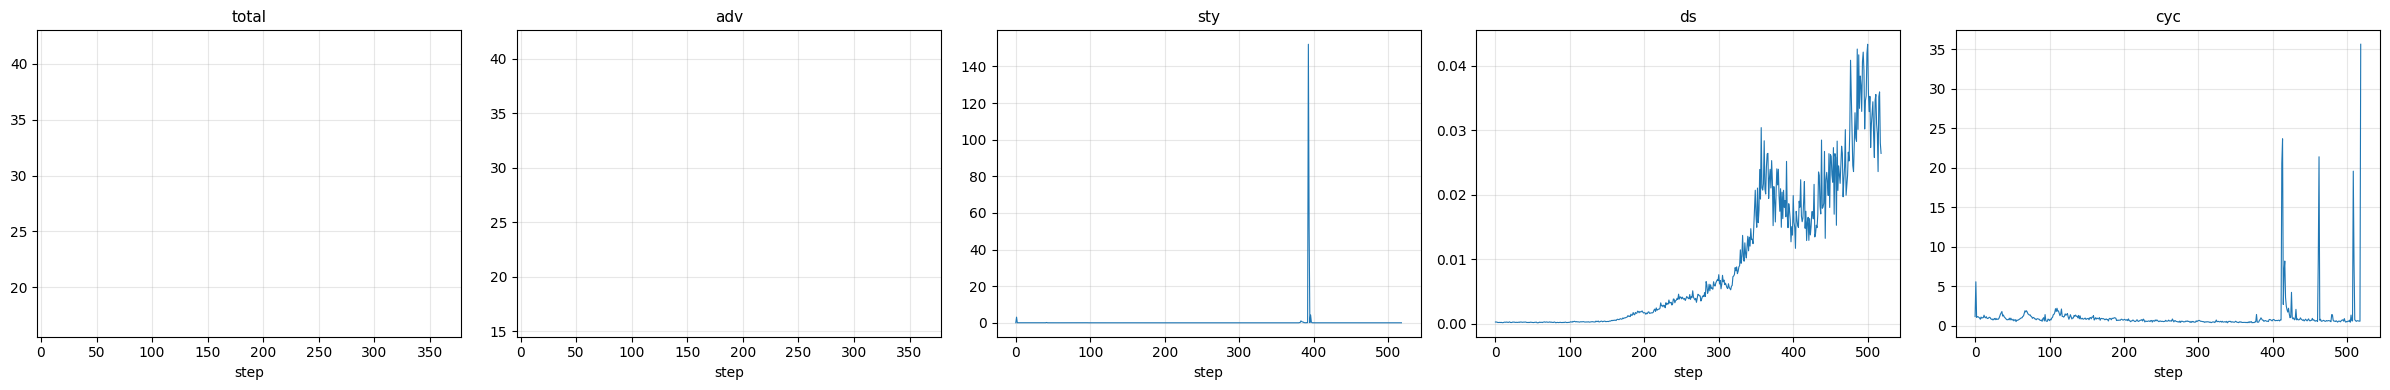

x_fake[0].shape=torch.Size([3, 256, 256])
x_fake[0].shape=torch.Size([3, 256, 256])
x_fake[0].shape=torch.Size([3, 256, 256])


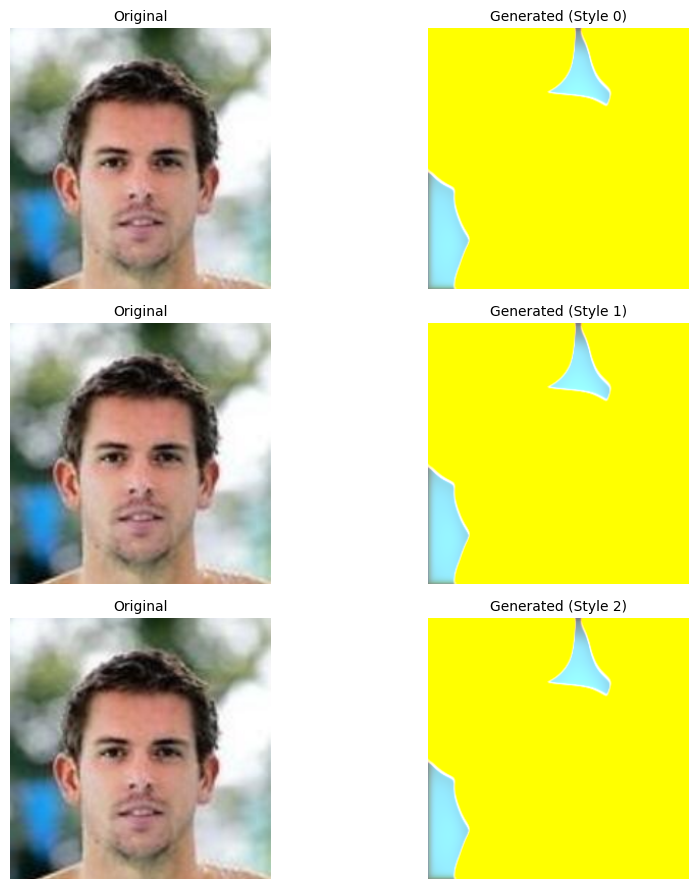

KeyboardInterrupt: 

In [59]:
for epoch in range(num_epochs):
    for i, (real_images, domains) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)):
        real_images = real_images.to(device)
        domains = domains.to(device)

        d_steps = 3
        g_steps = 1

        for _ in range(d_steps):
            loss_D = train_discriminator_step(
                discriminator, generator, mapping_network,
                real_images, domains, optim_D, device
            )
            # torch.cuda.empty_cache()

        for _ in range(g_steps):
            loss_G, l_adv_G, l_sty_G, l_ds_G, l_cyc_G = train_generator_step(
                generator, discriminator, style_encoder, mapping_network,
                real_images, domains, optim_G, optim_F, optim_E, device
            )
            # torch.cuda.empty_cache()

        loss_history["total"].append(loss_G)
        loss_history["adv"].append(l_adv_G)
        loss_history["sty"].append(l_sty_G)
        loss_history["ds"].append(l_ds_G)
        loss_history["cyc"].append(l_cyc_G)


        if i % 100 == 0:
            plot_loss_history(loss_history)
            visualize_generations_with_mapping(generator, mapping_network, dataloader, device, num_styles=3)

    scheduler_G.step()
    scheduler_D.step()
    scheduler_F.step()
    scheduler_E.step()

plot_loss_history(loss_history)

### Оценка модели

Для оценки качества сгенерированных изображений используется метрика LPIPS.

In [29]:
lpips = LPIPS()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jovyan/vasiliev/notebooks/DeepGenerativeModels/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jovyan/vasiliev/notebooks/DeepGenerativeModels/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/jovyan/vasiliev/notebooks/DeepGenerativeModels/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


In [30]:
test_iters = 100  # Количество итераций для тестирования модели
values = []

generator.eval()
style_encoder.eval()

with torch.no_grad():
    for i in trange(test_iters):
        x_real, _ = next(iter(dataloader))
        x_ref, _ = next(iter(dataloader))
        x_ref2, _ = next(iter(dataloader))
        
        batch_size = x_real.shape[0]
        
        # Случайное задание целевого и исходного доменов для каждого изображения
        y_trg = torch.tensor(np.random.choice(np.arange(DOMAINS_COUNT), size=batch_size))  # Целевой домен
        y_org = torch.tensor(np.random.choice(np.arange(DOMAINS_COUNT), size=batch_size))  # Исходный домен
        
        # Перенос данных на выбранное устройство и приведение типов
        x_real, x_ref, x_ref2 = [x.to(device).float() for x in [x_real, x_ref, x_ref2]]
        y_trg, y_org = [x.to(device).long() for x in [y_trg, y_org]]
        
        # Генерация изображения с использованием вашей модели
        # Извлекаем style codes из reference изображения
        style_codes_ref = style_encoder(x_ref)  # [batch_size, DOMAINS_COUNT, STYLE_CODE_DIM]
        
        # Выбираем style code для целевого домена y_trg
        selected_style_codes = style_codes_ref[torch.arange(batch_size, device=device), y_trg]
        
        # Генерируем изображение с применением стиля из x_ref к x_real
        x_fake = generator(x_real, selected_style_codes)
        
        # Вычисление LPIPS между сгенерированным и реальным изображением
        # LPIPS возвращает тензор [batch_size], нужно усреднить или добавить все значения
        lpips_values = lpips(x_fake.cpu(), x_real.cpu()).squeeze()  # [batch_size]
        
        # Добавляем все значения из батча
        values.extend(lpips_values.tolist())

print("Среднее значение LPIPS:", np.mean(values))
assert np.mean(values) < 1.3

100%|██████████| 100/100 [00:07<00:00, 13.41it/s]

Среднее значение LPIPS: 0.834827541410923


### Вывод результатов оценки

In [31]:
with torch.no_grad():
    z_trg = torch.randn((batch_size, args.latent_dim)).to(device)
    s_trg = nets.mapping_network(z_trg, y_trg)
    # s_trg = nets.style_encoder(x_ref2, y_trg) 
    x_fake = nets.generator(x_real, s_trg)

plt.figure(figsize=(6, 6))
plt.imshow(x_fake[1].permute(1, 2, 0).detach().cpu().numpy())
plt.title("Сгенерированное изображение")
plt.axis('off')
plt.show()

AttributeError: latent_dim

## Этап 3. Дополнительный анализ

В данном разделе рекомендуется провести дополнительные эксперименты и анализ:
- **Анализ латентного пространства**. *(2 балла)*
- **Текстовое ревью решения**: опишите, какие изменения можно внести для улучшения модели, и обоснуйте их. *(1 балл)*